In [3]:
from dash import Dash, html, dcc, dash_table, Input, Output, State
import sqlite3
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from textblob import TextBlob
import statsmodels.api as sm
import plotly.express as px
import plotly.graph_objects as go
import nltk

# -----------------------------
# Setup
# -----------------------------
pd.set_option("display.max_colwidth", None)
nltk.download("stopwords")

DB_PATH = r"C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Arkansas Tech Social Media/social_media.db"

# -----------------------------
# Load Data
# -----------------------------
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT * FROM post WHERE `Post type` = 'IG reel'", conn)
conn.close()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tyler\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [63]:
df["Description"] = df["Description"].astype(str)
df["sentiment"] = df["Description"].apply(lambda x: TextBlob(x).sentiment.polarity)
df["subjectivity"] = df["Description"].apply(lambda x: TextBlob(x).sentiment.subjectivity)
df["len_chars"] = df["Description"].apply(len)
df["len_words"] = df["Description"].apply(lambda x: len(x.split()))

In [56]:
df['Reach'] = pd.to_numeric(df['Reach'], errors='coerce')
df['Views'] = pd.to_numeric(df['Views'], errors='coerce')
df['Likes'] = pd.to_numeric(df['Likes'], errors='coerce')
df['Duration (sec)'] = pd.to_numeric(df['Duration (sec)'], errors='coerce')

df['LVR'] = (df['Likes'] / df['Views']) * 100
df['R_VR'] = (df['Reach'] / df['Views']) * 100

In [38]:
print(df.columns.tolist())

['Post ID', 'Account ID', 'Account username', 'Account name', 'Description', 'Duration (sec)', 'Publish time', 'Permalink', 'Post type', 'Data comment', 'Date', 'Views', 'Likes', 'Shares', 'Comments', 'Saves', 'Reach', 'Follows', 'cluster', 'Clusters', 'LVR']


In [11]:
var1 = 'Likes'
var2 = 'Views'
constant = 'Post type'

In [12]:
#k-means
from sklearn.cluster import KMeans
tocluster=df[[var1,var2]].dropna()
kmeans = KMeans(n_clusters=3,random_state=42)
kmeans.fit(tocluster)

C:\Users\tyler\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [14]:
#Apply CH to Different Numbers of Clusters:
from sklearn.metrics import calinski_harabasz_score
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.impute import SimpleImputer

# Create a copy of the data to avoid modifying the original
tocluster = df[[var1, var2]].copy()

# Handle missing values using SimpleImputer
# Strategy 'mean' replaces NaN with the mean of each column
imputer = SimpleImputer(strategy='mean')
tocluster_imputed = pd.DataFrame(
    imputer.fit_transform(tocluster),
    columns=tocluster.columns
)

# Now run the clustering on the imputed data
for i in range(2, 7):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(tocluster_imputed)
    ch_score = calinski_harabasz_score(tocluster_imputed, kmeans.labels_)
    print("Calinski–Harabasz Index for", i, "clusters:", ch_score)

Calinski–Harabasz Index for 2 clusters: 260.2578472279829
Calinski–Harabasz Index for 3 clusters: 285.31419360588535
Calinski–Harabasz Index for 4 clusters: 548.3905728646424
Calinski–Harabasz Index for 5 clusters: 687.1036307373308
Calinski–Harabasz Index for 6 clusters: 879.5772844392292


C:\Users\tyler\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\tyler\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\tyler\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\tyler\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

In [17]:
#Continuing with 5 clusters
from sklearn.cluster import KMeans
import numpy as np
from sklearn.impute import SimpleImputer

# Create a copy of the data to avoid modifying the original
tocluster = df[[var1, var2]].copy()

# Option 1: Drop rows with NaN values
# tocluster = tocluster.dropna()

# Option 2: Impute missing values (replace NaNs with mean)
imputer = SimpleImputer(strategy='mean')
tocluster_imputed = imputer.fit_transform(tocluster)

# Now apply KMeans on the cleaned data
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(tocluster_imputed)
clusters = kmeans.predict(tocluster_imputed)

# If you want to add the clusters back to the original dataframe
df['cluster'] = np.nan  # Initialize with NaN
df.loc[tocluster.index, 'cluster'] = clusters  # Assign only to rows that were clustered

C:\Users\tyler\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [19]:
#Look at cluster membership
df['cluster'] = clusters.tolist()
df.head()

,Post ID,Account ID,Account username,Account name,Description,Duration (sec),Publish time,Permalink,Post type,Data comment,Date,Views,Likes,Shares,Comments,Saves,Reach,Follows,cluster
0,17927394071816206,17841402627774708,atu_business,ATU LeMoyne Smith School of Business,"ICYMI: Decode the Clues with ATU, TOMORROW!",29,08/01/2024 09:08,https://www.instagram.com/reel/C-Ih3nmR6SU/,IG reel,None,Lifetime,872,11,2,0,0,504.0,0.0,2
1,17988368402736497,17841400588879469,_livjohnson34,liv 🍓,"Welcome back to another day of the life of a graduate assistant! Halloween is my favorite holiday, so I had to take you along with me 👻\n\n#GoodAsGold #ATU2024 #GraduateSchool #GraduateStudent #Halloween #Beetlejuice #ArkansasTech",45,10/31/2024 14:16,https://www.instagram.com/reel/DBzaM9Dy46p/,IG reel,None,Lifetime,1642,62,1,4,0,None,None,2
2,17864129277252817,17841402627774708,atu_business,ATU LeMoyne Smith School of Business,Cash Cow can’t wait to see all of her friends tomorrow for trick or treating at Rothwell!\n\nLook for “Trick or Treat” decorations to find the candy at:\n👻 Career Services\n👻 4th floor lobby and offices\n\nCostumes are encouraged!! Please bring your own basket!\n\n#heckyeahtechyeah #atubusiness #atu2024 #halloween #trickortreat,18,10/30/2024 10:00,https://www.instagram.com/reel/DBwYIhTPVox/,IG reel,None,Lifetime,1078,58,3,0,1,647.0,0.0,2
3,18057994513852516,17841402627774708,atu_business,ATU LeMoyne Smith School of Business,"Make your way to Rothwell 138 at noon today to hear about the Wall Street Experience - direct from us 🫡 join us during Spring Break next semester to experience Wall Street and more ✈️🏙️\n\nFor more info, contact jbrock15@atu.edu or DM us! \n\n#livefromnewyork #snl #domingo #atutravels #heckyeahtechyeah #collegelife #welcometonewyork",7,10/28/2024 09:11,https://www.instagram.com/reel/DBrIvxax_mL/,IG reel,None,Lifetime,1477,19,1,0,0,879.0,0.0,2
4,18240619846285920,17841468167257244,marketing_taylorsversion,None,The only scooters we allow in this class 💁🏼‍♀️🖤#marketingtaylorsversion #swiftie #taylorswift #reputation #reputationtaylorsversion #rep #reptv #getawaycar @taylorswift @taylornation @atu_business @arkansastech @kylierehberger,15,10/25/2024 11:02,https://www.instagram.com/reel/DBjnGKAvEci/,IG reel,None,Lifetime,941,23,1,2,0,None,None,2


In [21]:
df[var1] = pd.to_numeric(df[var1], errors='coerce')  # 'coerce' will convert non-convertible values to NaN
df[var2] = pd.to_numeric(df[var2], errors='coerce')

#cluster summary
p1=df.pivot_table(index="cluster",values=[var1,var2],aggfunc="mean")
p2=df.pivot_table(index="cluster",values=[Constant],aggfunc="count")
print("Cluster Means \n",p1)
print("\n \n Number of, {Constant}, per Cluster \n",p2)

Cluster Means 
               Likes         Views
cluster                          
0        145.904762   5497.400000
1        677.428571  17050.428571
2         59.493671   2010.430380

 
 Number of, {Constant}, per Cluster 
          Post type
cluster           
0               42
1                7
2               79


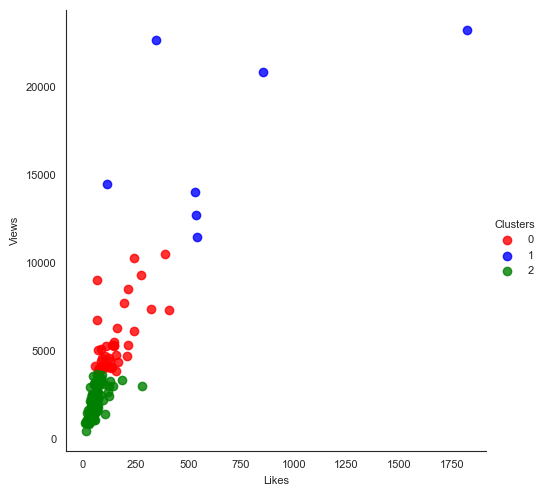

In [22]:
#plotting clusters
import seaborn as sns
import matplotlib.pyplot as plt
df["Clusters"]=clusters
#set font size of labels on matplotlib plots
plt.rc('font', size=8)
sns.set_style('white')
#set the colors used in the graph, see https://xkcd.com/color/rgb/
customPalette = ['red', 'blue', 'green', 'yellow', 'black' ]
sns.set_palette(customPalette)
#plot data with seaborn
facet = sns.lmplot(data=df, x=var1, y=var2, hue='Clusters',
fit_reg=False, legend=True)

In [66]:
cluster_0 = df[df['cluster']==0].copy()
cluster_1 = df[df['cluster']==1].copy()
cluster_2 = df[df['cluster']==2].copy()

In [86]:
import pyperclip

# Convert DataFrame to string and copy to clipboard
result = cluster_1[['Permalink', 'Likes', 'Views', 'Reach', 'LVR', 'R_VR', 'Duration (sec)', 'sentiment', 'subjectivity']].sort_values(
    by=['LVR', 'R_VR'], 
    ascending=[False, True]
)
pyperclip.copy(result.to_string())

In [72]:
LVR_mean = cluster_0['LVR'].mean()
high_lvr = cluster_0[cluster_0['LVR'] > LVR_mean]
print(high_lvr[['Duration (sec)', 'sentiment', 'subjectivity']].mean())

Duration (sec)    34.333333
sentiment          0.081284
subjectivity       0.246562
dtype: float64


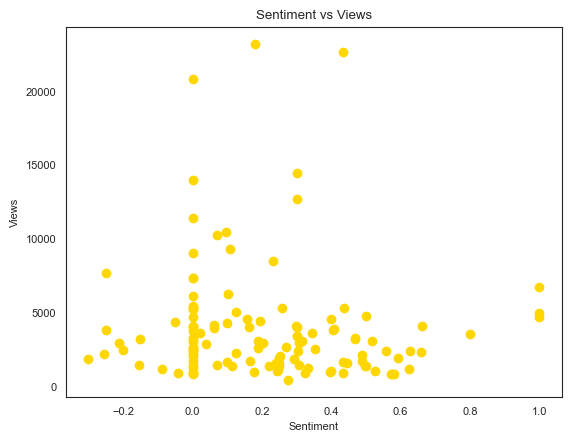

In [81]:
import matplotlib.pyplot as plt

plt.scatter(df['sentiment'], df['Views'], color='Gold')
plt.xlabel('Sentiment')
plt.ylabel('Views')
plt.title('Sentiment vs Views')
plt.show()